# FER2013 Classifier

## Imports & Device Agnostic Code

In [20]:
# Import needed libraries
import torch
import torchvision
from torch import nn
import helper_functions as hf

from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader

from pathlib import Path
import requests
import zipfile

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from datetime import datetime
import os

from typing import Dict, List, Tuple

from timeit import default_timer as timer

# Install tensorboard
import sys
!{sys.executable} -m pip install -q tensorboard
from torch.utils.tensorboard import SummaryWriter

# Install torchinfo, import if it's available
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary

!pip install -q torchmetrics mlxtend
import torchmetrics
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

import random

In [10]:
# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"


## Data

In [39]:
# Get FER2013 data from Kaggle

import os
from getpass import getpass

# 1. Set Kaggle credentials
os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass("Kaggle API key: ")

# 2. Make clean data directory
!rm -rf data/fer2013
!mkdir -p data/fer2013

# 3. Download FER2013 CSV-style dataset
!kaggle datasets download \
    -d debanga/facial-expression-recognition-challenge \
    -p data/fer2013

# 4. Unzip and flatten files into data/fer2013
# The -j flag prevents weird nested folders like icml_face_data.csv/icml_face_data.csv
!unzip -q -o -j data/fer2013/facial-expression-recognition-challenge.zip -d data/fer2013

# 5. Check downloaded files
!ls -lh data/fer2013
!file data/fer2013/icml_face_data.csv


Dataset URL: https://www.kaggle.com/datasets/debanga/facial-expression-recognition-challenge
License(s): unknown
100% 321M/321M [00:04<00:00, 78.6MB/s] 

total 1.1G
-rw-r--r-- 1 root root 7.1K Apr 23  2020 example_submission.csv
-rw-r--r-- 1 root root  18M Apr 23  2020 face_embs.npy
-rw-r--r-- 1 root root 322M Apr 23  2020 facial-expression-recognition-challenge.zip
-rw-r--r-- 1 root root  92M Apr 23  2020 fer2013.tar
-rw-r--r-- 1 root root 288M Apr 23  2020 icml_face_data.csv
-rw-r--r-- 1 root root 288M Apr 23  2020 metadata_processed.csv
-rw-r--r-- 1 root root  58M Apr 23  2020 test.csv
data/fer2013/icml_face_data.csv: CSV text


Length of train data: 28709
Length of test data: 7178
Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7f07dfa1d0d0>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x7f083ee7deb0>
Class names: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
Shape of first piece of data: torch.Size([1, 48, 48]) | label: 0


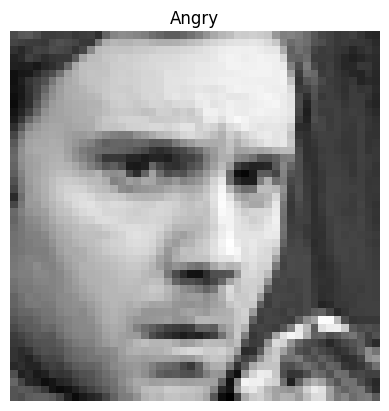

In [52]:
# Set data directory
DATA_DIR = Path("data")

# Get data
train_data = datasets.FER2013(root="data",
                              split="train",
                              transform=transforms.ToTensor()
)

test_data = datasets.FER2013(root="data",
                             split="test",
                             transform=transforms.ToTensor()
)

# Make dataloaders
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

# Get classes
class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
class_to_idx = {
    "Angry": 0,
    "Disgust": 1,
    "Fear": 2,
    "Happy": 3,
    "Sad": 4,
    "Surprise": 5,
    "Neutral": 6
}

X, y = train_data[0]

print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")
print(f"Train dataloader: {train_dataloader}")
print(f"Test dataloader: {test_dataloader}")
print(f"Class names: {class_names}")
print(f"Shape of first piece of data: {X.shape} | label: {y}")

hf.plot_image(img=X,
              class_names=class_names,
              label=y,
              cmap="gray",
              axis_state=False)